# ARMA Model — System Identification Walkthrough

This notebook demonstrates the four-step system identification process for a univariate time series using the **ARMA** model class.

| Step | Task | Tool |
|------|------|------|
| 1 | Choose a model class | Domain knowledge |
| 2 | Select model order | `uniAnal` — ACF, PACF, GPAC |
| 3 | Estimate parameters | `estimate`, `pmoddisp` |
| 4 | Validate the model | `uniAnal` on residuals, `uniChi` |

**Dataset:** Box-Jenkins Series A — Chemical Concentration (197 observations)


The ARMA($n_d$, $n_c$) model is

$$D(q)\,y(t) = C(q)\,e(t)$$

where

$$D(q) = 1 + d_1 q^{-1} + \cdots + d_{n_d} q^{-n_d}$$

and

$$C(q) = 1 + c_1 q^{-1} + \cdots + c_{n_c} q^{-n_c}$$

The noise is modeled by the transfer function $H(q) = C(q)/D(q)$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import pandas as pd

# Add TimeSeries root directory to path
current_dir = os.getcwd()
timeseries_root = os.path.abspath(os.path.join(current_dir, '..', '..', '..'))
if timeseries_root not in sys.path:
    sys.path.insert(0, timeseries_root)

from TimeSeriesSRC.Model.model import pmodel
from TimeSeriesSRC.Model.estimate import estimate
from TimeSeriesSRC.Model.selpmod import func_selpmod as selpmod
from TimeSeriesSRC.basefunctions.uniAnal import func_uniAnal as uniAnal
from TimeSeriesSRC.basefunctions.uniChi import func_uniChi as uniChi
from TimeSeriesSRC.basefunctions.partoacf import func_partoacf_pmod as partoacf_pmod
from TimeSeriesSRC.Model.pmodmse import func_pmodmse as pmodmse
from TimeSeriesSRC.Model.pmoddisp import func_pmoddisp as pmoddisp
from TimeSeriesSRC.Model.pmoddisp import func_pmodpzplot as pmodpzplot

np.random.seed(42)
print('Setup complete.')



Setup complete.


## Series A — Chemical Concentration

Box-Jenkins Series A is a univariate time series of 197 concentration measurements from a chemical process.  There is no observed external input, making the ARMA class the natural starting point.  The series mean is removed before modeling.

In [3]:
data_path = os.path.join(timeseries_root, 'TimeSeriesSRC', 'TestData', 'Series_A_Chemical_Concentration.csv')
df = pd.read_csv(data_path)
y = np.array(df['Concentration'])


## Step 1 — Choose a Model Class

With no external input, the general prediction model $y(t) = G(q)u(t) + H(q)e(t)$ reduces to a pure noise model:

$$y(t) = H(q)\,e(t) = \frac{C(q)}{D(q)}\,e(t)$$

This is the **ARMA($n_d$, $n_c$)** model, where $D(q)$ is the autoregressive polynomial of order $n_d$ and $C(q)$ is the moving average polynomial of order $n_c$.  The orders are determined in Step 2.

Loaded chemical process data: N=197 samples
y: mean=-2.74e-15, std=0.398


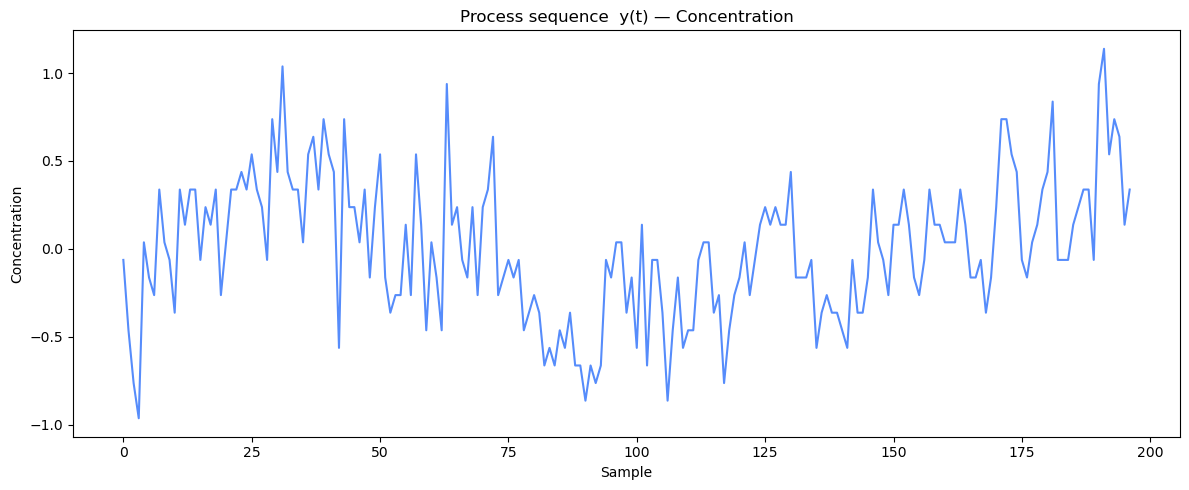

In [3]:
y = y - np.mean(y)
N = y.size
print(f'Loaded chemical process data: N={N} samples')
print(f'y: mean={y.mean():.2e}, std={y.std():.3f}')

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(y)
ax.set_title('Process sequence  y(t) — Concentration')
ax.set_xlabel('t')
ax.set_ylabel('Concentration')
ax.set_xlabel('Sample')
plt.tight_layout()
plt.show()

## Step 2 — Select Model Order

`uniAnal` computes the ACF, PACF, and Generalized Partial Autocorrelation (GPAC) of the series.

- **ACF** — exponential or oscillatory decay suggests AR behaviour; a sharp cutoff at lag $n_c$ suggests a pure MA model.
- **PACF** — cuts off sharply after lag $n_d$ for a pure AR model; decays slowly for a pure MA model.
- **GPAC** — the primary tool for ARMA order identification.  A column of approximately constant (near-zero) entries identifies the AR order $n_d$; the row at which the constant pattern begins identifies the MA order $n_c$.

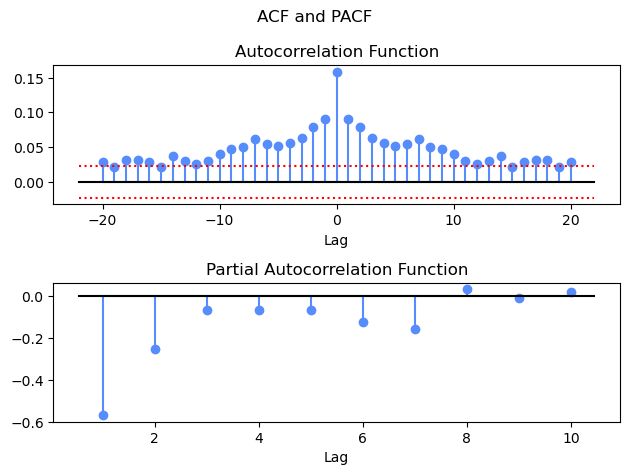

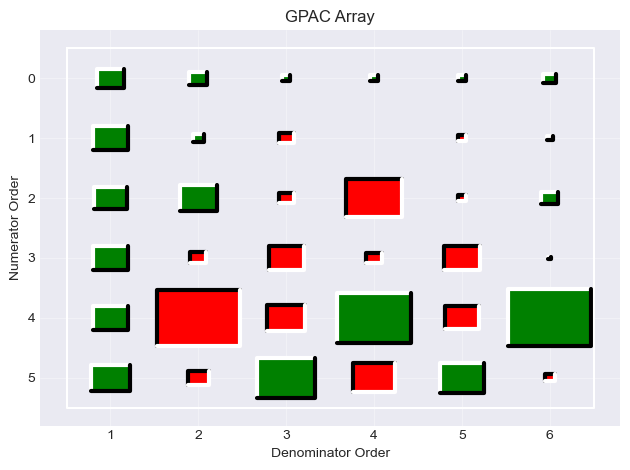

In [4]:
acf, pacf, gpac = uniAnal(y, na=20, nump=10, nrg=6, ncg=6)

### GPAC Interpretation

In the GPAC table, look for a **column that becomes approximately constant** (values near zero from some row onward):

- The **column index** is the candidate AR order $n_d$.
- The **row where the constant pattern begins** is the candidate MA order $n_c$.

For Series A, column 1 of the GPAC becomes approximately constant starting at row 1, indicating an **ARMA(1, 1)** model ($n_d = 1$, $n_c = 1$).

## Step 3 — Estimate Parameters

We fit an **ARMA(1, 1)** model — the structure indicated by the GPAC — using `estimate`, which minimises the sum of squared one-step prediction errors via the Levenberg–Marquardt algorithm.

`pmoddisp` prints the estimated parameters with ±2σ confidence intervals and a confidence-interval plot.  `pmodpzplot` shows the pole-zero map for the noise transfer function $H(q) = C(q)/D(q)$, confirming stability and invertibility.

Epoch 0/100 Time 0.0007948875427246094 PMODMSE 0.18876863441748454/0 Gradient 34.47996692994865/0.0001 mu 0.001/10000000000.0


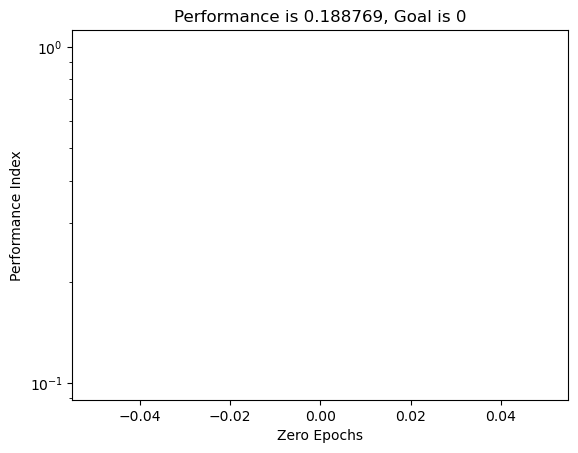

Epoch 10/100 Time 0.1499190330505371 PMODMSE 0.09816324220471359/0 Gradient 0.0028234427030654425/0.0001 mu 1.0000000000000006e-10/10000000000.0


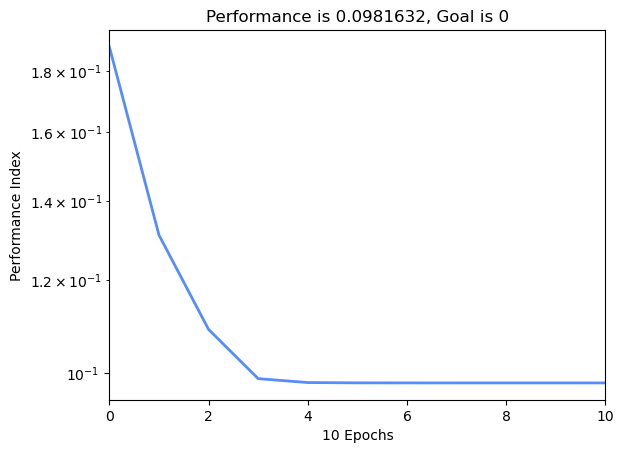

6.114089507982792e-05 0.0001
Epoch 15/100 Time 0.22534489631652832 PMODMSE 0.09816323622692254/0 Gradient 6.114089507982792e-05/0.0001 mu 1.0000000000000009e-15/10000000000.0


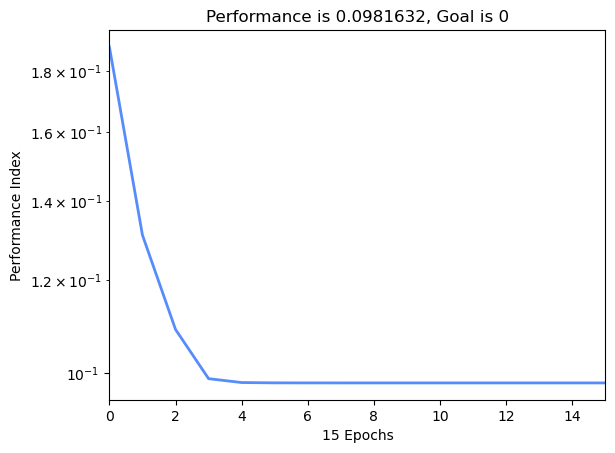

ESTIMLM, Minimum gradient reached, performance goal was not met.




In [5]:
pmod = pmodel('arma', nc=[1], nd=[1], diff=[0], per=[])
pmod, trec, stat = estimate(pmod, y)

Parameter estimates — ARMA model
--------------------------------
  Param        Value          ±2σ   95% CI
  ----------------------------------------
  c1      -0.5536       0.1762   (   -0.7297,    -0.3774)
  d1      -0.9010       0.0936   (   -0.9946,    -0.8073)

  Residual std  σ = 0.313310
  Residual var  σ² = 0.098163


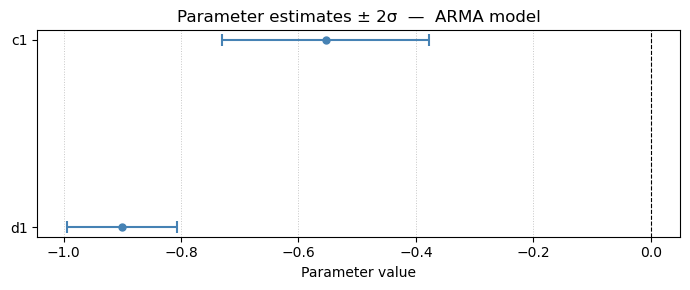

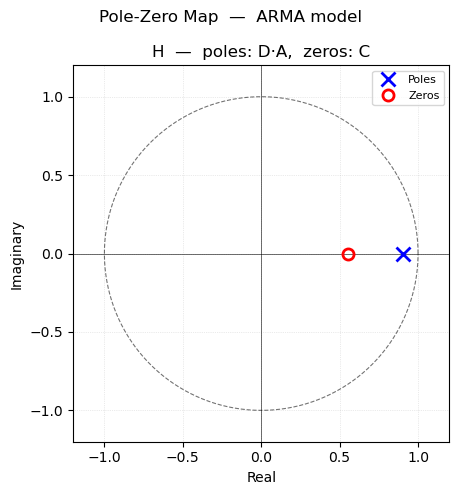

In [6]:
pmoddisp(pmod, stat)
pmodpzplot(pmod)
plt.show()

## Step 4 — Validate the Model

A well-fitted ARMA model should leave **white residuals** — uncorrelated errors with no remaining structure.  We check this in three ways:

1. **Theoretical ACF** — `partoacf_pmod` computes the theoretical autocovariance function of the fitted model using the Yule-Walker method.  Overlaying it on the experimental ACF from Step 2 confirms that the model captures the correlation structure of the data.
2. **Residual ACF** — plot the ACF, PACF, and GPAC of the residuals with `uniAnal`.  All values should fall within the 95% confidence bounds (dashed lines).
3. **Statistical test** — `uniChi` performs the portmanteau chi-square test on the residuals.  The null hypothesis is that the residuals are white noise; a p-value > 0.05 indicates an adequate model.

### Check 1 — Theoretical vs Experimental ACF

`partoacf_pmod` uses the Yule-Walker equations to compute the exact autocovariance function implied by the fitted ARMA polynomials and the noise variance.  Close agreement with the experimental ACF from Step 2 confirms that the model has captured the dominant correlation structure.

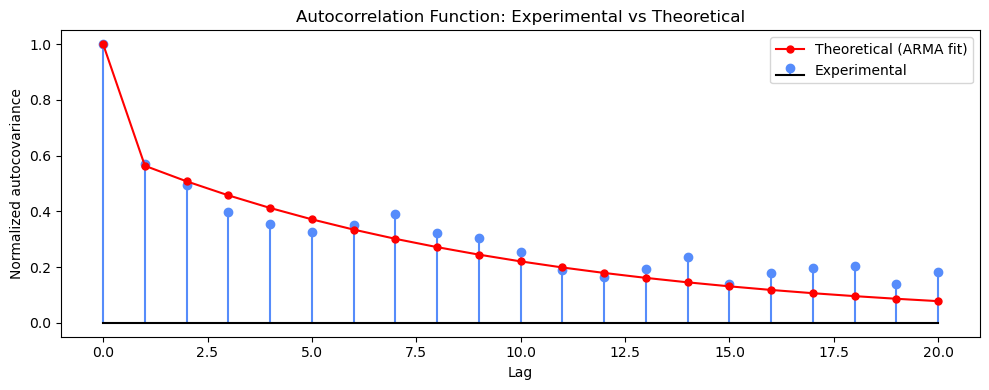

In [7]:
# Noise variance estimate from one-step prediction errors
var_e, _ = pmodmse(pmod, y)

# Theoretical autocovariance function from the fitted ARMA(1,1) model
lagmax = 21
acf_theory, _, _ = partoacf_pmod(pmod, var_e, lagmax)

# Experimental ACF from Step 2: uniAnal returned acf of shape (1, 2*na+1)
# with na=20, so index 20 is lag 0; take the positive-lag half
acf_exp = acf.squeeze()[20:20 + lagmax]

# Normalize both to lag-0 = 1 for a shape comparison
acf_theory_norm = acf_theory / acf_theory[0]
acf_exp_norm    = acf_exp    / acf_exp[0]

lags = np.arange(lagmax)

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(lags, acf_exp_norm, linefmt='C0-', markerfmt='C0o', basefmt='k-', label='Experimental')
ax.plot(lags, acf_theory_norm, 'r-o', markersize=5, linewidth=1.5, label='Theoretical (ARMA fit)')
ax.set_title('Autocorrelation Function: Experimental vs Theoretical')
ax.set_xlabel('Lag')
ax.set_ylabel('Normalized autocovariance')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
e = y - pmod.predict(y)
print(f'Residual std: {e.std():.4f}')
acf_e, pacf_e, gpac_e = uniAnal(e, na=20, nump=10, nrg=6, ncg=6)

In [8]:
#uniChi(pmod, y)

passed, q_arma, n_arma, pval = uniChi(pmod, y)

print(f'\nChi-square test on u residuals:  Q={q_arma:.2f},  df={n_arma},  pass={bool(passed)}, pval={pval:.3f}')
print('(pass=True means residuals are consistent with white noise at 95% confidence)')


pval: 0.1040045634909047
alpha: 0.05
pr: 0.8959954365090953
q: 25.82270352305808

Chi-square test on u residuals:  Q=25.82,  df=18,  pass=True, pval=0.104
(pass=True means residuals are consistent with white noise at 95% confidence)


## Conclusion

The residual ACF is within the 95% confidence bounds (approximating an impulse function), the first row of the GPAC is approximately zero (indicating white noise) and the chi-square test is passed (p-value > 0.05), therefore the **ARMA(1, 1)** model is validated. .

The fitted parameter table from `pmoddisp` shows the estimated values with ±2σ confidence intervals, and none of the confidence intervals includes zero, which would indicate that a parameter could be removed.  The pole-zero map from `pmodpzplot` confirms whether the AR and MA polynomials are stable and invertible — all poles and zeros should lie outside the unit circle. Also, there is no approximate pole/zero cancellation, which would indicate that the model orders could be reduced.

If the residuals show remaining structure, return to **Step 2** and explore higher-order structures, or use `selpmod` for an automated grid search over ARMA orders.

## Automated Model Selection with `selpmod`

`selpmod` performs a grid search over a set of candidate ARMA structures, estimating each one and ranking by AIC and BIC.  We search over $n_d \in \{1, 2, 3\}$ and $n_c \in \{0, 1, 2, 3\}$ — 12 combinations — to verify that the **ARMA(1, 1)** structure identified in Step 2 is indeed optimal.

In [9]:
arma_spec = {
    'models': [{
        'type': 'arma',
        'nc': [0, 1, 2, 3],
        'nd': [1, 2, 3],
        'diff': [0]
    }]
}
result  = selpmod(arma_spec, y)
aicmod  = result['arma']['aicmod']
bicmod  = result['arma']['bicmod']
aicstat = result['arma']['aicstat']
bicstat = result['arma']['bicstat']

Selecting the best ARMA prediction model
arma: Combination 1 out of 12 total  [nc=0, nd=1].  aic = -2.2262, bic = -2.2096
arma: Combination 2 out of 12 total  [nc=0, nd=2].  aic = -2.2818, bic = -2.2485
arma: Combination 3 out of 12 total  [nc=0, nd=3].  aic = -2.2771, bic = -2.2271
arma: Combination 4 out of 12 total  [nc=1, nd=1].  aic = -2.3008, bic = -2.2675
arma: Combination 5 out of 12 total  [nc=1, nd=2].  aic = -2.3013, bic = -2.2513
arma: Combination 6 out of 12 total  [nc=1, nd=3].  aic = -2.2966, bic = -2.2299
arma: Combination 7 out of 12 total  [nc=2, nd=1].  aic = -2.2979, bic = -2.2479
arma: Combination 8 out of 12 total  [nc=2, nd=2].  aic = -2.2818, bic = -2.2151
arma: Combination 9 out of 12 total  [nc=2, nd=3].  aic = -2.2846, bic = -2.2013
arma: Combination 10 out of 12 total  [nc=3, nd=1].  aic = -2.2983, bic = -2.2317
arma: Combination 11 out of 12 total  [nc=3, nd=2].  aic = -2.2809, bic = -2.1975
arma: Combination 12 out of 12 total  [nc=3, nd=3].  aic = -2.3180

Best AIC model: ARMA(nd=3, nc=3)
Best BIC model: ARMA(nd=1, nc=1)

=== Best AIC model ===
Parameter estimates — ARMA model
--------------------------------
  Param        Value          ±2σ   95% CI
  ----------------------------------------
  c1      -1.6897       0.1603   (   -1.8500,    -1.5294)
  c2       1.6609       0.1663   (    1.4946,     1.8271)
  c3      -0.6489       0.1576   (   -0.8065,    -0.4912)
  d1      -2.0100       0.0935   (   -2.1035,    -1.9165)
  d2       1.9745       0.1165   (    1.8580,     2.0910)
  d3      -0.9062       0.0861   (   -0.9923,    -0.8202)

  Residual std  σ = 0.304386
  Residual var  σ² = 0.092651


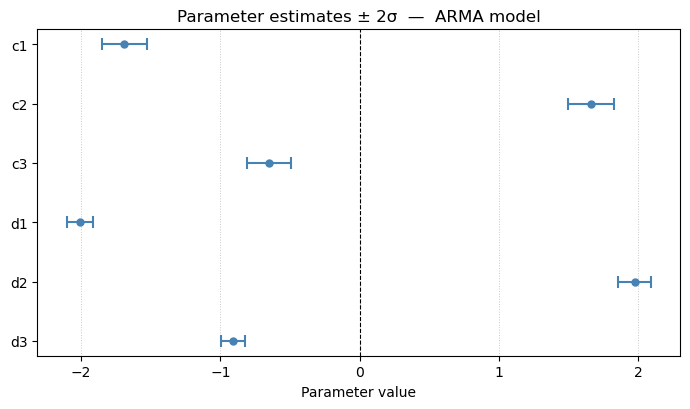

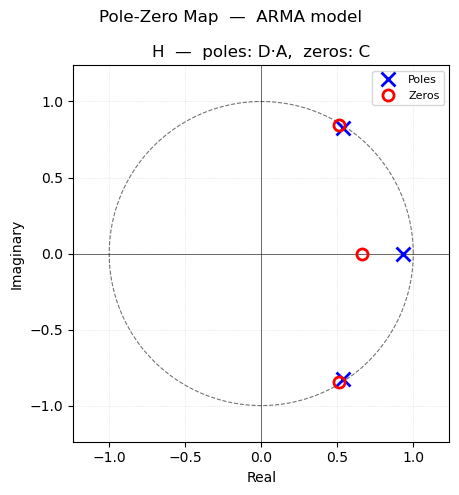

=== Best BIC model ===
Parameter estimates — ARMA model
--------------------------------
  Param        Value          ±2σ   95% CI
  ----------------------------------------
  c1      -0.5536       0.1762   (   -0.7297,    -0.3774)
  d1      -0.9010       0.0936   (   -0.9946,    -0.8073)

  Residual std  σ = 0.313310
  Residual var  σ² = 0.098163


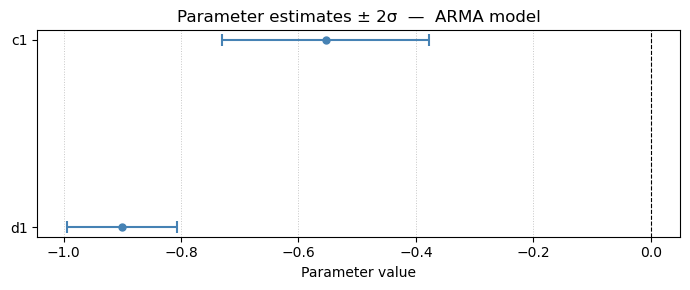

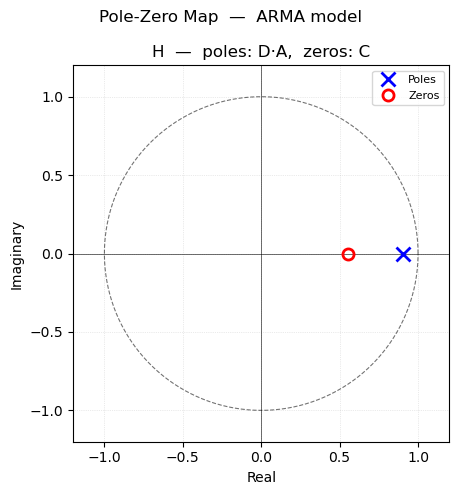

In [10]:
print(f'Best AIC model: ARMA(nd={int(aicmod.nd[0])}, nc={int(aicmod.nc[0])})')
print(f'Best BIC model: ARMA(nd={int(bicmod.nd[0])}, nc={int(bicmod.nc[0])})\n')

print('=== Best AIC model ===')
pmoddisp(aicmod, aicstat)
pmodpzplot(aicmod)
plt.show()

print('=== Best BIC model ===')
pmoddisp(bicmod, bicstat)
pmodpzplot(bicmod)
plt.show()

Notice that the best AIC model increased nc and nd by 2. However, when we look at the pole / zero plot, we see that there are pole / zero cancellations. After the cancellation, we revert back to the original model. The best BIC model is the same as the original model we selected from the preliminary analysis.